# Groundwater Level Forecasting – Statistical ARIMAX with Lagged NA

This notebook implements a **purely statistical baseline model**
using ARIMAX (SARIMAX) with:

- Same datasets used in the LSTM model
- Same temporal filtering
- Only natural explanatory variables
- Explicit lagged groundwater level (NA) as memory term

Steps:
- Load and merge data
- Period selection
- Feature engineering (natural + NA lag)
- Train/Test split (time-based)
- ARIMAX model fitting
- Forecasting
- Evaluation
- Residual diagnostics

Configuration

In [223]:
# ======================================================
# Experiment configuration
# ======================================================

SUBSET_NAME = "subset2"      # subset1 | subset2
ENGINEERED_MODE = "all"      # lag_only | all

FORCE_RETRAIN = False

SUBSET_PERIODS = {
    "subset1": (
        "2022-05-11 15:30:00",
        "2022-07-11 11:00:00"
    ),
    "subset2": (
        "2024-12-08 23:00:00",
        "2025-08-14 16:00:00"
    )
}

## 0. Imports

In [224]:
%pip install statsmodels pmdarima

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [225]:
# ======================================================
# Imports and configuration
# ======================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

OUTPUT_DIR = "arima_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

## 1. Load and Merge Data (same as LSTM notebook)

In [226]:
# ======================================================
# Paths
# ======================================================
BASE_PATH = "."

path_level_rain_pressure = os.path.join(
    BASE_PATH, "data/nivel-pocos_chuva_pressao_tratados.csv"
)
path_wells_func = os.path.join(
    BASE_PATH, "data/funcionamento_pocos_30min.csv"
)
path_earth_tide = os.path.join(
    BASE_PATH, "data/earth_tide.csv"
)

# ======================================================
# Load data
# ======================================================
level_rain_pressure = pd.read_csv(path_level_rain_pressure)
wells_func = pd.read_csv(path_wells_func)
earth_tide = pd.read_csv(path_earth_tide)

# ======================================================
# Standardize datetime column
# ======================================================
if "datetime" in earth_tide.columns:
    earth_tide = earth_tide.rename(columns={"datetime": "date_time"})

for df_ in [level_rain_pressure, wells_func, earth_tide]:
    if "date_time" not in df_.columns:
        raise ValueError("Dataset missing 'date_time' column.")

# ======================================================
# Rename variables
# ======================================================
rename_map = {
    "pressao_mH2O_final": "baro_ig_mH2O",
    "gmu_level_mH2O_compensado": "gmu_gwl_mH2O",
    "chuva_mm_30min": "rain_mm_30min",
    "status_IMECC": "status_IME",
    "status_ZOOLOGIA": "status_IBZ",
}

level_rain_pressure = level_rain_pressure.rename(columns=rename_map)
wells_func = wells_func.rename(columns=rename_map)

# ======================================================
# Clean pumping status
# ======================================================
wells_func = wells_func.dropna()
pumping_cols = wells_func.columns.difference(["date_time"])
wells_func[pumping_cols] = wells_func[pumping_cols].astype(int)

# ======================================================
# Merge datasets
# ======================================================
data = (
    level_rain_pressure
    .merge(wells_func, on="date_time", how="outer")
    .merge(earth_tide, on="date_time", how="outer")
)

data["date_time"] = pd.to_datetime(data["date_time"])
data = data.sort_values("date_time").reset_index(drop=True)

print("Merged shape:", data.shape)

Merged shape: (70080, 8)


## 2. Period Selection (same window as LSTM)

In [227]:
# ======================================================
# Filter analysis period
# ======================================================
START_DATE, END_DATE = SUBSET_PERIODS[SUBSET_NAME]

data = data[
    (data["date_time"] >= START_DATE) &
    (data["date_time"] <= END_DATE)
].copy()

print(f"Using period {START_DATE} → {END_DATE}")
print("Shape after filtering:", data.shape)

# ======================================================
# Set time index
# ======================================================
df = data.set_index("date_time").copy()

Using period 2024-12-08 23:00:00 → 2025-08-14 16:00:00
Shape after filtering: (11939, 8)


## 3. Feature Engineering – Natural Drivers + Lagged NA

In [228]:
# ======================================================
# Target
# ======================================================
target_col = "gmu_gwl_mH2O"

# ======================================================
# Feature engineering
# ======================================================

# --- autoregressive ---
df["gwl_lag_6h"] = df[target_col].shift(12)
df["gwl_diff_24h"] = df[target_col] - df[target_col].shift(48)

# --- trend ---
df["trend_component"] = (
    df[target_col]
    .rolling(window=336, center=False, min_periods=1)
    .mean()
)

# --- pumping ---
pumping_cols = ["status_IME", "status_FEF", "status_IBZ"]
df["pumping_total"] = df[pumping_cols].sum(axis=1)

df["pumping_sum_7d"] = (
    df["pumping_total"]
    .rolling(window=336, min_periods=1)
    .sum()
)

# --- rainfall ---
df["rain_sum_7d"] = (
    df["rain_mm_30min"]
    .rolling(window=336, min_periods=1)
    .sum()
)

# --- calendar ---
df["weekday"] = (df.index.weekday < 5).astype(int)

# ======================================================
# Engineered feature selection
# ======================================================
engineered_features_all = [
    "gwl_lag_6h",
    "gwl_diff_24h",
    "trend_component",
    "pumping_sum_7d",
    "rain_sum_7d",
    "weekday",
]

if ENGINEERED_MODE == "all":
    engineered_features = engineered_features_all
elif ENGINEERED_MODE == "lag_only":
    engineered_features = ["gwl_lag_6h"]
else:
    raise ValueError("Invalid ENGINEERED_MODE")

# ======================================================
# Natural features
# ======================================================
excluded_cols = (
    [target_col] +
    engineered_features_all +
    ["pumping_total"]
)

natural_features = [
    c for c in df.columns if c not in excluded_cols
]

# ======================================================
# Final feature set
# ======================================================
if ENGINEERED_MODE == "lag_only":
    candidate_features = ["gwl_lag_6h"]
else:
    candidate_features = natural_features + engineered_features

print("Engineered mode:", ENGINEERED_MODE)
print("Final features:", candidate_features)

# ======================================================
# Final modeling dataframe
# ======================================================
df_model = df[[target_col] + candidate_features].copy()

valid_mask = df_model.notna().all(axis=1).values
df_sarimax = df_model.loc[valid_mask].copy()

print("SARIMAX-ready shape:", df_sarimax.shape)


Engineered mode: all
Final features: ['baro_ig_mH2O', 'rain_mm_30min', 'status_IME', 'status_FEF', 'status_IBZ', 'earth_tide_nm/s2', 'gwl_lag_6h', 'gwl_diff_24h', 'trend_component', 'pumping_sum_7d', 'rain_sum_7d', 'weekday']
SARIMAX-ready shape: (11891, 13)


## 4. Train / Test Split (time-based)

In [229]:
# ======================================================
# Train / validation / test split (time-aware)
# ======================================================

n = len(df_sarimax)

train_end = int(n * 0.70)
val_end   = int(n * 0.85)   # 70% + 15%

df_train = df_sarimax.iloc[:train_end]
df_val   = df_sarimax.iloc[train_end:val_end]
df_test  = df_sarimax.iloc[val_end:]

# Targets
y_train = df_train[target_col]
y_val   = df_val[target_col]
y_test  = df_test[target_col]

# Exogenous features
X_train = df_train[candidate_features]
X_val   = df_val[candidate_features]
X_test  = df_test[candidate_features]

# ======================================================
# Diagnostics
# ======================================================
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (8323, 12) (8323,)
Val  : (1784, 12) (1784,)
Test : (1784, 12) (1784,)


In [230]:
# ======================================================
# Normalization — FIT on TRAIN only (NO DATA LEAKAGE)
# ======================================================

from sklearn.preprocessing import StandardScaler

# Inicializa scaler
scaler = StandardScaler()

# Ajusta SOMENTE no treino
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index,
    columns=X_train.columns
)

# Aplica a MESMA transformação em validação e teste
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    index=X_val.index,
    columns=X_val.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index,
    columns=X_test.columns
)

# ======================================================
# Diagnostics
# ======================================================
print("Scaled shapes:")
print("Train:", X_train_scaled.shape)
print("Val  :", X_val_scaled.shape)
print("Test :", X_test_scaled.shape)

print("\nTRAIN mean (≈0):")
display(X_train_scaled.mean())

print("\nTRAIN std (≈1):")
display(X_train_scaled.std())


Scaled shapes:
Train: (8323, 12)
Val  : (1784, 12)
Test : (1784, 12)

TRAIN mean (≈0):


baro_ig_mH2O       -1.434916e-14
rain_mm_30min       2.731872e-17
status_IME         -1.195194e-17
status_FEF         -1.400084e-16
status_IBZ          5.293001e-17
earth_tide_nm/s2    6.829679e-18
gwl_lag_6h          3.756323e-17
gwl_diff_24h        2.475759e-17
trend_component    -6.146711e-17
pumping_sum_7d      1.297639e-16
rain_sum_7d        -3.414840e-18
weekday             1.698883e-16
dtype: float64


TRAIN std (≈1):


baro_ig_mH2O        1.00006
rain_mm_30min       1.00006
status_IME          1.00006
status_FEF          1.00006
status_IBZ          1.00006
earth_tide_nm/s2    1.00006
gwl_lag_6h          1.00006
gwl_diff_24h        1.00006
trend_component     1.00006
pumping_sum_7d      1.00006
rain_sum_7d         1.00006
weekday             1.00006
dtype: float64

## 5. ARIMAX Model Fitting (SARIMAX)

In [231]:
MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    f"{SUBSET_NAME}_ARIMAX_{ENGINEERED_MODE}.pkl"
)

SCALER_PATH = os.path.join(
    OUTPUT_DIR,
    f"{SUBSET_NAME}_ARIMAX_{ENGINEERED_MODE}_scaler.pkl"
)

In [232]:
# ======================================================
# Fit SARIMAX (using normalized TRAIN features)
# ======================================================
if (
    os.path.exists(MODEL_PATH)
    and
    os.path.exists(SCALER_PATH)
    and
    not FORCE_RETRAIN
):

    print("Loading saved ARIMAX model...")

    results = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)

else:

    print("Training ARIMAX model...")

    model = SARIMAX(
        y_train,
        exog=X_train_scaled,
        order=(3,0,0),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    results = model.fit(disp=False)

    joblib.dump(
        results,
        MODEL_PATH
    )

    joblib.dump(
        scaler,
        SCALER_PATH
    )

    print("Model saved.")

print(results.summary())

Loading saved ARIMAX model...
                               SARIMAX Results                                
Dep. Variable:           gmu_gwl_mH2O   No. Observations:                 8323
Model:               SARIMAX(3, 0, 0)   Log Likelihood               29995.094
Date:                Wed, 17 Jun 2026   AIC                         -59958.188
Time:                        20:50:54   BIC                         -59845.765
Sample:                    12-09-2024   HQIC                        -59919.783
                         - 06-01-2025                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
baro_ig_mH2O        -0.0226      0.001    -21.400      0.000      -0.025      -0.021
rain_mm_30min       -0.0002   4.02e-05     -4.255      0.000      -0.000   -9.22e-0

## 6. Forecast on Test Period & Evaluation Metrics

In [233]:
# ======================================================
# Prediction — TEST only (CORRECT & FINAL)
# ======================================================

n_test = len(y_test)

forecast_res = results.get_forecast(
    steps=n_test,
    exog=X_test_scaled
)

y_test_pred = forecast_res.predicted_mean

# Alinhamento explícito do índice
y_test_pred.index = y_test.index

# ======================================================
# Metrics — TEST
# ======================================================

r2   = r2_score(y_test, y_test_pred)
mae  = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
nse  = 1 - np.sum((y_test - y_test_pred)**2) / np.sum((y_test - y_test.mean())**2)
bias = np.mean(
    y_test_pred - y_test
)

rrmse = (
    rmse /
    (y_test.max() - y_test.min())
) * 100

print("\nARIMAX performance — TEST:")
print(f"R²  = {r2:.4f}")
print(f"MAE = {mae:.4f}")
print(f"RMSE= {rmse:.4f}")
print(f"NSE = {nse:.4f}")
print(f"Bias= {bias:.4f}")
print(f"RRMSE= {rrmse:.2f} %")

results_table = pd.DataFrame([{
    "subset": SUBSET_NAME,
    "mode": ENGINEERED_MODE,
    "R2": r2,
    "NSE": nse,
    "MAE": mae,
    "RMSE": rmse
}])

results_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_ARIMAX_{ENGINEERED_MODE}_metrics.csv"
    ),
    index=False
)

display(results_table)

summary_df = pd.DataFrame([{
    "subset": SUBSET_NAME,
    "mode": ENGINEERED_MODE,
    "R2": r2,
    "NSE": nse,
    "MAE": mae,
    "RMSE": rmse,
    "Bias": bias,
    "rRMSE_percent": rrmse,
    "Residual_mean": residuals.mean() if "residuals" in locals() else np.nan
}])

summary_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_ARIMAX_{ENGINEERED_MODE}_summary.csv"
    ),
    index=False
)




ARIMAX performance — TEST:
R²  = -1.2926
MAE = 1.0491
RMSE= 1.1072
NSE = -1.2926
Bias= -1.0450
RRMSE= 43.38 %


,subset,mode,R2,NSE,MAE,RMSE
0,subset2,all,-1.292594,-1.292594,1.049131,1.107197


## 8. Visualization – Observed vs Predicted

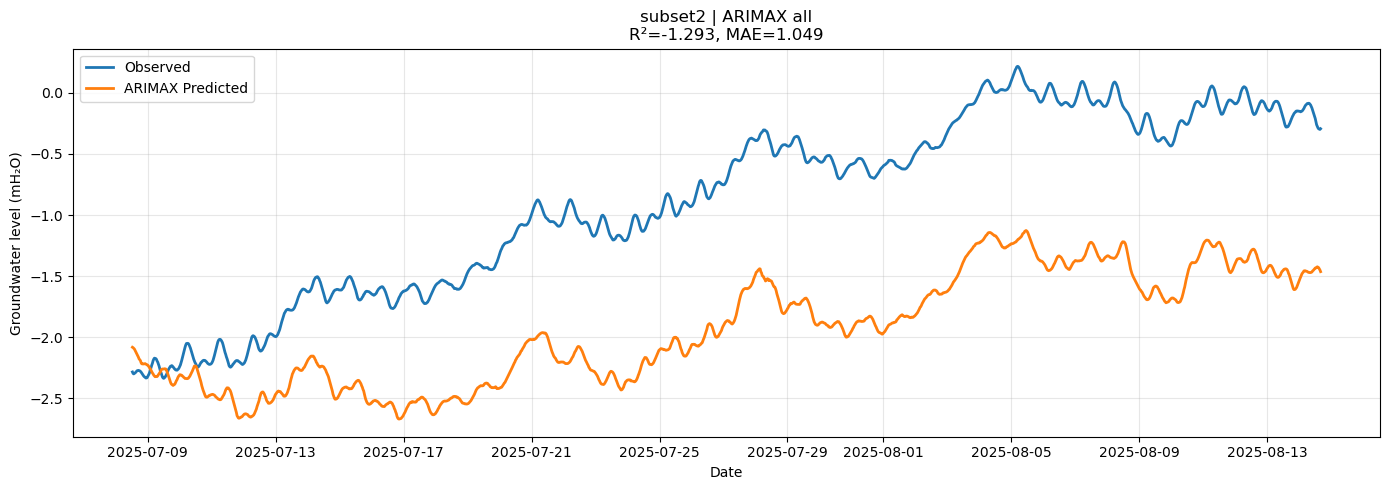

In [234]:
# ======================================================
# Plot prediction — TEST only (Matplotlib default colors)
# ======================================================

plt.figure(figsize=(14, 5))

# Observed
plt.plot(
    y_test.index,
    y_test.values,
    label="Observed",
    linewidth=2
)

# Predicted
plt.plot(
    y_test_pred.index,
    y_test_pred.values,
    label="ARIMAX Predicted",
    linewidth=2
)

plt.title(
    f"{SUBSET_NAME} | ARIMAX {ENGINEERED_MODE}\n"
    f"R²={r2:.3f}, MAE={mae:.3f}"
)

plt.xlabel("Date")
plt.ylabel("Groundwater level (mH₂O)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

pred_df = pd.DataFrame({
    "observed": y_test,
    "predicted": y_test_pred
})

pred_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_ARIMAX_{ENGINEERED_MODE}_predictions.csv"
    )
)

In [235]:
import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Variância absoluta das variáveis exógenas (TRAIN only)
# ----------------------------------------------------------
var_abs = X_train.var()

var_df = (
    pd.DataFrame({
        "feature": var_abs.index,
        "variance": var_abs.values
    })
    .sort_values("variance", ascending=False)
)

print("Absolute variance of exogenous features (TRAIN):")
display(var_df)

# ----------------------------------------------------------
# Coeficiente de variação (std / |mean|)
# ----------------------------------------------------------
mean_vals = X_train.mean()
std_vals  = X_train.std()

cv = std_vals / mean_vals.abs()
cv = cv.replace([np.inf, -np.inf], np.nan)

cv_df = (
    pd.DataFrame({
        "feature": cv.index,
        "coef_variation": cv.values
    })
    .sort_values("coef_variation", ascending=False)
)

print("Coefficient of variation (scale-free, TRAIN):")
display(cv_df)

# ----------------------------------------------------------
# Identificar features quase constantes
# ----------------------------------------------------------
low_var_threshold = 1e-6

low_var_features = var_abs[var_abs < low_var_threshold]

print("Near-zero variance features (TRAIN):")
if low_var_features.empty:
    print("  None")
else:
    for f, v in low_var_features.items():
        print(f" - {f}: variance = {v:.2e}")


Absolute variance of exogenous features (TRAIN):


,feature,variance
5,earth_tide_nm/s2,479978.117101
9,pumping_sum_7d,35662.805927
10,rain_sum_7d,1057.141076
6,gwl_lag_6h,7.622128
8,trend_component,7.298447
1,rain_mm_30min,0.582014
3,status_FEF,0.247190
2,status_IME,0.245781
4,status_IBZ,0.244578
11,weekday,0.203641


Coefficient of variation (scale-free, TRAIN):


,feature,coef_variation
1,rain_mm_30min,10.249599
7,gwl_diff_24h,4.577821
5,earth_tide_nm/s2,4.556242
6,gwl_lag_6h,2.116599
8,trend_component,1.922229
10,rain_sum_7d,1.300762
3,status_FEF,1.112977
2,status_IME,0.877176
4,status_IBZ,0.861836
11,weekday,0.630818


Near-zero variance features (TRAIN):
  None


## 9. Residual Diagnostics

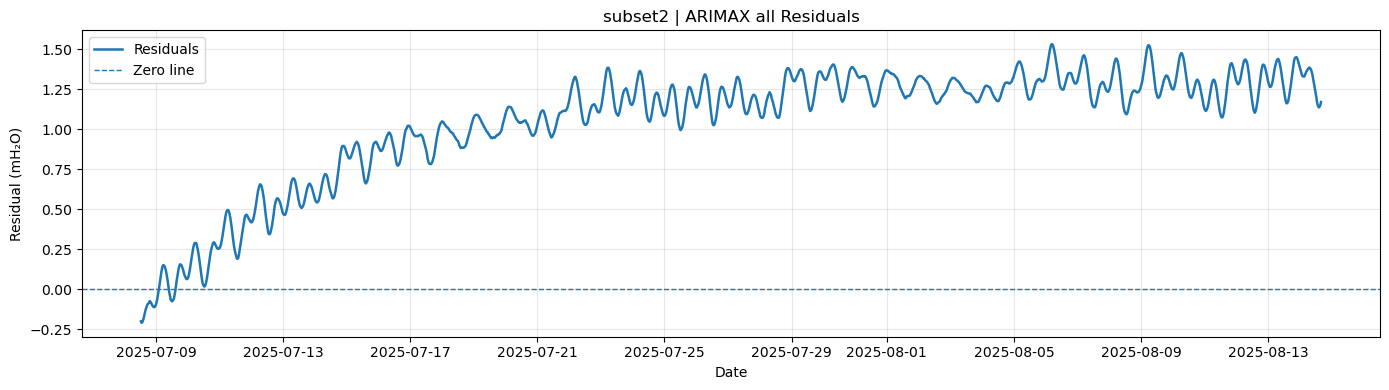

Residual mean: 1.0449595436056958
Residual std : 0.3660858173975543


In [236]:
# ======================================================
# Residual analysis — TEST only (Matplotlib default)
# ======================================================

residuals = y_test - y_test_pred

residual_df = pd.DataFrame({
    "residual": residuals
})

residual_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"{SUBSET_NAME}_ARIMAX_{ENGINEERED_MODE}_residuals.csv"
    )
)

plt.figure(figsize=(14, 4))

plt.plot(
    residuals.index,
    residuals.values,
    linewidth=1.8,
    label="Residuals"
)

plt.axhline(
    0,
    linewidth=1,
    linestyle="--",
    label="Zero line"
)

plt.title(
    f"{SUBSET_NAME} | ARIMAX {ENGINEERED_MODE} Residuals"
)
plt.xlabel("Date")
plt.ylabel("Residual (mH₂O)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Residual mean:", residuals.mean())
print("Residual std :", residuals.std())
